# Classical ML Models — Rain in Australia

This notebook trains and evaluates four classical ML models for predicting **RainTomorrow** (binary):
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

All model pipelines are defined in `classical_models.py`.

**Primary evaluation metric:** ROC-AUC (per cahier de charge).

## 1 — Imports & Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from classical_models import get_all_models, evaluate_model, FEATURE_COLUMNS, TARGET_RAIN

DATA_PATH   = "data/clean_data.csv"
MODELS_DIR  = "saved_models/"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Imports OK")

/home/limam/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports OK


## 2 — Data Loading

In [2]:
# Load a small HEAD for schema validation only
df_schema = pd.read_csv(DATA_PATH, nrows=5)
print("Columns:", df_schema.columns.tolist())
print("Shape preview:", df_schema.shape)

df = pd.read_csv(DATA_PATH)
X = df[FEATURE_COLUMNS]
y = df[TARGET_RAIN]
print(f"Full dataset: {X.shape}")
print(f"Rain prevalence: {y.mean():.2%}")

Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Month', 'TempRange', 'Humidity_Avg', 'Pressure_Diff', 'WindDir3pm_sin', 'WindDir3pm_cos', 'City_Encoded', 'Month_sin', 'Month_cos']
Shape preview: (5, 28)
Full dataset: (145460, 21)
Rain prevalence: 21.91%


## 3 — Train / Test Split

In [3]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Critical: preserve ~22% rain ratio
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Rain prevalence — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")
print("Split logic ready — uncomment above cells to execute.")

Train: (116368, 21), Test: (29092, 21)
Rain prevalence — Train: 21.91%, Test: 21.91%
Split logic ready — uncomment above cells to execute.


## 4 — Model Instantiation Check

In [4]:
# Verify all 4 models instantiate without error
models = get_all_models()
for name, pipeline in models.items():
    clf_name = type(pipeline.steps[-1][1]).__name__
    print(f"\u2705 {name}: {clf_name}")

✅ logistic_regression: LogisticRegression
✅ decision_tree: DecisionTreeClassifier
✅ random_forest: RandomForestClassifier
✅ xgboost: XGBClassifier


## 5 — Cross-Validation Setup

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy", "precision", "recall"]

cv_results = {}
for name, pipeline in models.items():
    print(f"\nRunning CV for {name}...")
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_strategy, scoring=scoring,
        n_jobs=-1, return_train_score=True
    )
    cv_results[name] = scores
    print(f"  ROC-AUC: {scores['test_roc_auc'].mean():.4f} \u00b1 {scores['test_roc_auc'].std():.4f}")
    print(f"  F1:      {scores['test_f1'].mean():.4f} \u00b1 {scores['test_f1'].std():.4f}")
    print(f"  Accuracy:{scores['test_accuracy'].mean():.4f} \u00b1 {scores['test_accuracy'].std():.4f}")
print("CV strategy defined — uncomment above to run.")


Running CV for logistic_regression...
  ROC-AUC: 0.8511 ± 0.0026
  F1:      0.5968 ± 0.0034
  Accuracy:0.7783 ± 0.0013

Running CV for decision_tree...
  ROC-AUC: 0.8440 ± 0.0015
  F1:      0.5906 ± 0.0008
  Accuracy:0.7733 ± 0.0030

Running CV for random_forest...
  ROC-AUC: 0.8732 ± 0.0020
  F1:      0.6345 ± 0.0026
  Accuracy:0.8158 ± 0.0008

Running CV for xgboost...


/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:13:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:13:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:13:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:13:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/pytho

  ROC-AUC: 0.8801 ± 0.0025
  F1:      0.6404 ± 0.0042
  Accuracy:0.8111 ± 0.0019
CV strategy defined — uncomment above to run.


## 6 — Fit & Save Models

In [6]:
for name, pipeline in models.items():
    print(f"Fitting {name}...")
    pipeline.fit(X_train, y_train)
    save_path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(pipeline, save_path)
    print(f"  Saved: {save_path}")
print("Fit + save logic ready — uncomment to execute.")

Fitting logistic_regression...
  Saved: saved_models/logistic_regression.joblib
Fitting decision_tree...
  Saved: saved_models/decision_tree.joblib
Fitting random_forest...
  Saved: saved_models/random_forest.joblib
Fitting xgboost...


/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:14:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Saved: saved_models/xgboost.joblib
Fit + save logic ready — uncomment to execute.


## 7 — ROC Curve Visualisation

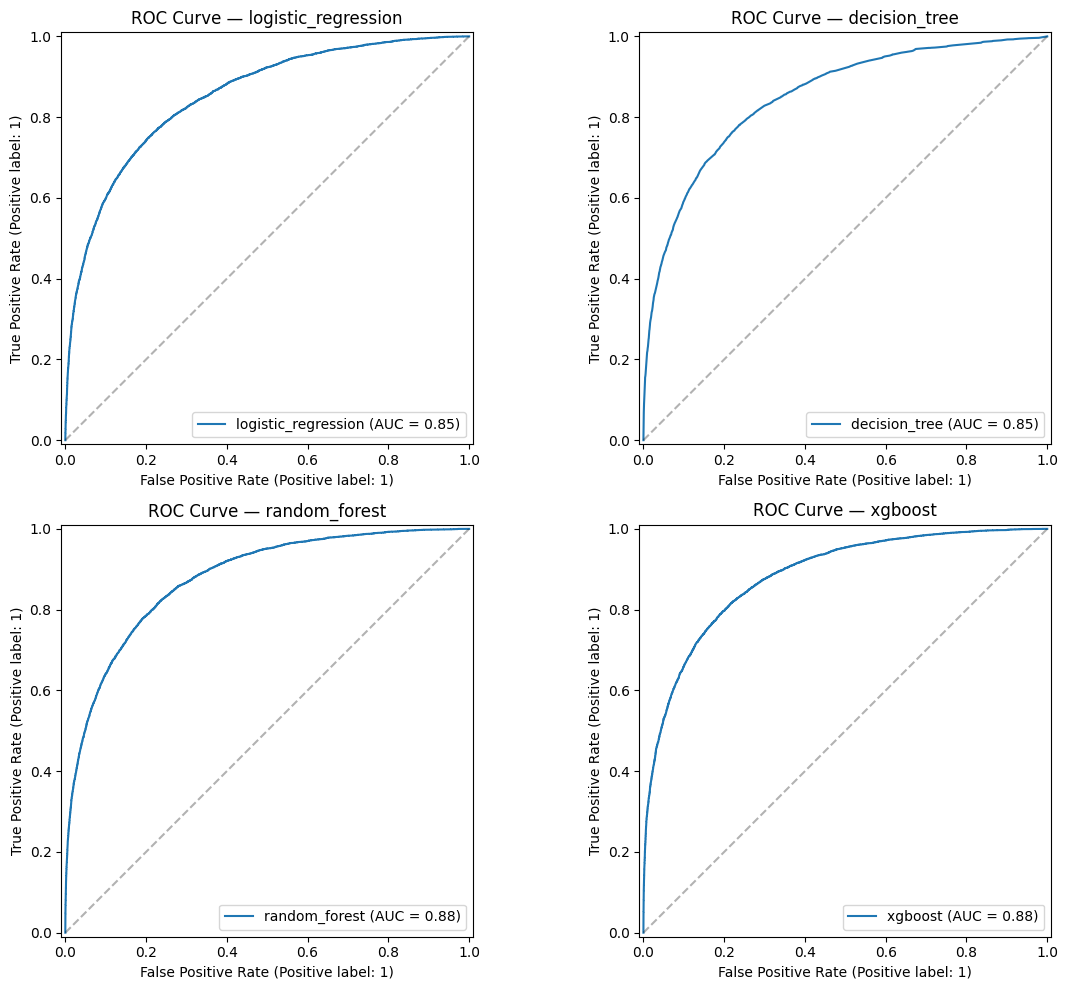

In [7]:
TRAINED = True  

if TRAINED:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (name, pipeline) in zip(axes.flat, models.items()):
        RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve — {name}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    plt.tight_layout()
    plt.savefig("artifacts/fig_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("\u23ed Skipping plots — set TRAINED=True after fitting models.")

## 8 — Results Summary Table

In [9]:
if TRAINED:
    summary_rows = []
    for name, pipeline in models.items():
        metrics = evaluate_model(pipeline, X_test, y_test)
        summary_rows.append({"Model": name, **metrics})

    summary_df = pd.DataFrame(summary_rows).set_index("Model")
    summary_df = summary_df.drop(columns=["confusion_matrix"])
    print(summary_df.sort_values("roc_auc", ascending=False).to_markdown())
else:
    print("\u23ed Skipping summary — set TRAINED=True after fitting models.")

| Model               |   accuracy |   roc_auc |   f1_score |   precision |   recall |
|:--------------------|-----------:|----------:|-----------:|------------:|---------:|
| xgboost             |   0.809776 |  0.883681 |   0.64158  |    0.546387 | 0.776941 |
| random_forest       |   0.816032 |  0.877667 |   0.638866 |    0.560568 | 0.742588 |
| logistic_regression |   0.778186 |  0.852227 |   0.600112 |    0.496005 | 0.759529 |
| decision_tree       |   0.773683 |  0.850175 |   0.597358 |    0.489526 | 0.766118 |
